# Giai đoạn 9 — Tinh chỉnh mở rộng

Giai đoạn 8 dò **14 cấu hình** mỗi tầng và thấy khoảng cách giữa cấu hình tốt nhất
và tệ nhất khá hẹp. Câu hỏi đặt ra: *đó là vì siêu tham số thật sự không quan trọng,
hay vì lưới tìm kiếm quá nhỏ?*

Notebook này trả lời dứt điểm bằng ba việc:

1. **Dò rộng gấp ~9 lần** trên lưới mở rộng mạnh về phía regularization
   (Giai đoạn 8 chọn `min_child_weight` = 10 và `reg_lambda` = 10 — đều là giá trị
   **lớn nhất** trong lưới cũ, dấu hiệu nó bị chặn).
2. **Đưa trọng số nguồn `w_nguồn` vào cùng vòng tìm** — đây là nghi phạm chính của
   khoảng cách học thuộc 77,7%, và nó không phải siêu tham số của XGBoost.
3. **Quét độ nhạy `w_nguồn`** riêng để có đường cong sạch cho báo cáo.

Mọi thứ dùng **đúng bộ fold và đúng thước đo** của Giai đoạn 8 để so sánh công bằng.

In [1]:
import pandas as pd
import numpy as np
import json
import time
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score,
                             classification_report, confusion_matrix)

# ── Thiết lập kiểu biểu đồ dùng chung cho toàn bộ báo cáo ────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

# Bảng màu thống nhất
C_THAT  = "#D64550"   # dữ liệu thật
C_GA    = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH  = "#3B7DD8"   # nhấn mạnh chính
C_CAM   = "#E8873A"   # nhấn mạnh phụ
C_TIM   = "#8E5FBF"
C_XAM   = "#AEB6BF"   # nền / mốc so sánh
C_DAM   = "#2C3E50"
C_KHOI  = ["#3B7DD8", "#E8873A", "#8E5FBF", "#19A2A2", "#D64550", "#C9A227", "#5D6D7E"]


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    # Ghi số ở cuối mỗi thanh ngang
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    # Ghi số trên đầu mỗi cột dọc
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=-0.02):
    # Dòng chú giải nằm dưới hình — nêu kết luận rút ra từ biểu đồ
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def luu(fig, thu_muc, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(thu_muc / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 Đã lưu hình: {ten}")

MR_DIR     = Path("../data/processed/07_model_ready")
SPLIT_DIR  = Path("../data/processed/02_split")
SYNTH_DIR  = Path("../data/processed/04_synthetic")
GD8_DIR    = Path("../data/processed/08_model")      # chỉ ĐỌC mốc so sánh
OUTPUT_DIR = Path("../data/processed/09_tinh_chinh")  # mọi kết quả GĐ9 ghi vào đây
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

X_train = pd.read_csv(MR_DIR / "X_train.csv")
X_test  = pd.read_csv(MR_DIR / "X_test.csv")
y_tr_n  = pd.read_csv(MR_DIR / "y_train_nganh.csv")["target_nganh"].to_numpy()
y_te_n  = pd.read_csv(MR_DIR / "y_test_nganh.csv")["target_nganh"].to_numpy()
y_tr_k  = pd.read_csv(MR_DIR / "y_train_khoi.csv")["target_khoi"].to_numpy()
y_te_k  = pd.read_csv(MR_DIR / "y_test_khoi.csv")["target_khoi"].to_numpy()
w_tr    = pd.read_csv(MR_DIR / "w_train.csv")["sample_weight"].to_numpy()
is_real = pd.read_csv(MR_DIR / "is_real_train.csv")["is_real"].to_numpy()
M       = np.load(MR_DIR / "M_nganh_khoi.npy")

Z  = np.load(SYNTH_DIR / "synthetic_per_fold.npz")
CV = json.load(open(SPLIT_DIR / "cv_folds_real.json", encoding="utf-8"))
LB = json.load(open(MR_DIR / "label_encoder_mapping.json", encoding="utf-8"))
FN = json.load(open(MR_DIR / "feature_names.json", encoding="utf-8"))

TEN_NGANH   = [LB["idx_to_name"][str(i)] for i in range(39)]
TEN_KHOI    = [LB["khoi_to_name"][str(i)] for i in range(7)]
LIKERT_COLS = FN["likert_cols"]

N_REAL = int(is_real.sum())
assert is_real[:N_REAL].all() and not is_real[N_REAL:].any(), "Dòng thật phải nằm ở đầu X_train"
X_syn_base = X_train.iloc[N_REAL:].reset_index(drop=True)
folds_all = CV["folds"]
folds_tim = [f for f in folds_all if f["repeat"] == 0]

print(f"Train : {len(X_train):,} dòng  ({N_REAL} thật + {len(X_syn_base):,} tổng hợp), "
      f"{X_train.shape[1]} đặc trưng")
print(f"Test  : {len(X_test)} dòng thật")
print(f"CV    : {len(folds_all)} fold  |  tìm siêu tham số trên {len(folds_tim)} fold")

Train : 14,370 dòng  (574 thật + 13,796 tổng hợp), 43 đặc trưng
Test  : 102 dòng thật
CV    : 15 fold  |  tìm siêu tham số trên 5 fold


## Bước 9.1 — Bộ khung, có thêm núm vặn trọng số

Giống hệt Giai đoạn 8, chỉ thêm tham số `ty_le_that`: nhân trọng số các **dòng thật**
lên/xuống, giữ nguyên trọng số dòng tổng hợp.

`ty_le_that = 1.0` tái lập chính xác Giai đoạn 8 (dòng thật nặng gấp ~24 lần dòng tổng
hợp, tổng trọng số hai bên bằng nhau). Giá trị nhỏ hơn 1 làm dòng thật nhẹ đi → model
khó học thuộc chúng hơn.

In [2]:
from sklearn.metrics import f1_score, balanced_accuracy_score
from xgboost import XGBClassifier
import time

W_THAT_TONG = w_tr[:N_REAL].sum()
W_SYN_TONG  = w_tr[N_REAL:].sum()
print(f"Trọng số hiện tại — thật: {W_THAT_TONG:,.0f}   tổng hợp: {W_SYN_TONG:,.0f}"
      f"   (tỉ lệ {W_THAT_TONG/W_SYN_TONG:.3f})")
print(f"Một dòng thật nặng gấp {w_tr[:N_REAL].mean()/w_tr[N_REAL:].mean():.1f} lần một dòng tổng hợp\n")


def lap_fold_w(f, ty_le_that=1.0):
    # Như Giai đoạn 8, nhưng nhân trọng số dòng THẬT với ty_le_that
    tr, va = np.asarray(f["train_idx"]), np.asarray(f["val_idx"])
    fid = f["fold"]
    Xs = X_syn_base.copy()
    Xs[LIKERT_COLS]    = Z[f"likert_{fid}"].astype(int)
    Xs["gioi_tinh_ma"] = Z[f"gioi_{fid}"].astype(int)
    Xs["muc_tieu_ma"]  = Z[f"muctieu_{fid}"].astype(int)
    return (pd.concat([X_train.iloc[tr], Xs], ignore_index=True),
            np.concatenate([y_tr_k[tr], y_tr_k[N_REAL:]]),
            np.concatenate([y_tr_n[tr], y_tr_n[N_REAL:]]),
            np.concatenate([w_tr[tr] * ty_le_that, w_tr[N_REAL:]]),
            X_train.iloc[va], y_tr_k[va], y_tr_n[va])


def fit_xgb(params, X, y, w, n_class, Xv, yv):
    p = dict(objective="multi:softprob", num_class=n_class, eval_metric="mlogloss",
             tree_method="hist", random_state=SEED, verbosity=0, n_jobs=-1,
             early_stopping_rounds=40, **params)
    m = XGBClassifier(**p)
    m.fit(X, y, sample_weight=w, eval_set=[(Xv, yv)], verbose=False)
    return m


def topk(y, P, k):
    return float(np.mean([y[i] in np.argpartition(-P[i], k)[:k] for i in range(len(y))]))


def cham_diem(params, ty_le_that, n_class, folds):
    # Trả về macro-F1, top-3 và khoảng cách train-val (đo trên dòng thật)
    f1s, t3s, gaps = [], [], []
    for f in folds:
        Xtr, ytk, ytn, wt, Xva, yvk, yvn = lap_fold_w(f, ty_le_that)
        yt, yv = (ytk, yvk) if n_class == 7 else (ytn, yvn)
        m = fit_xgb(params, Xtr, yt, wt, n_class, Xva, yv)
        P = m.predict_proba(Xva)
        f1s.append(f1_score(yv, P.argmax(1), average="macro", zero_division=0))
        t3s.append(topk(yv, P, 3))
        n_that = len(f["train_idx"])
        P_tr = m.predict_proba(Xtr.iloc[:n_that])
        gaps.append(float((P_tr.argmax(1) == yt[:n_that]).mean() - (P.argmax(1) == yv).mean()))
    return float(np.mean(f1s)), float(np.mean(t3s)), float(np.mean(gaps))

print("Sẵn sàng.")

Trọng số hiện tại — thật: 7,242   tổng hợp: 7,128   (tỉ lệ 1.016)
Một dòng thật nặng gấp 24.4 lần một dòng tổng hợp

Sẵn sàng.


## Bước 9.2 — Dò rộng

Lưới mở rộng so với Giai đoạn 8 ở mọi chiều, đặc biệt:

| Tham số | Giai đoạn 8 | Giai đoạn 9 |
|---|---|---|
| `max_depth` | 3–8 | **2–10** |
| `min_child_weight` | 1–10 | **1–50** |
| `reg_lambda` | 1–10 | **0,1–100** |
| `reg_alpha` | 0–0,5 | **0–10** |
| `gamma` | 0–0,5 | **0–5** |
| `max_delta_step` | — | **0–5** *(mới — giúp lớp mất cân bằng)* |
| `ty_le_that` | cố định 1,0 | **0,15–2,0** *(mới)* |

Chọn theo **macro-F1 trên VAL thật**, y hệt Giai đoạn 8, để so sánh được trực tiếp.

In [3]:
KHONG_GIAN = {
    "max_depth":        [2, 3, 4, 5, 6, 8, 10],
    "learning_rate":    [0.01, 0.02, 0.03, 0.05, 0.08, 0.12, 0.20],
    "n_estimators":     [600],
    "subsample":        [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.3, 0.4, 0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 6, 10, 15, 20, 30, 50],
    "reg_alpha":        [0.0, 0.1, 0.5, 2.0, 5.0, 10.0],
    "reg_lambda":       [0.1, 1.0, 3.0, 10.0, 30.0, 100.0],
    "gamma":            [0.0, 0.1, 0.5, 1.0, 2.0, 5.0],
    "max_delta_step":   [0, 1, 3, 5],
}
TY_LE_THAT_CHON = [0.15, 0.25, 0.4, 0.6, 0.8, 1.0, 1.5, 2.0]
N_THU = {1: 80, 2: 120}          # tầng 1 rẻ hơn nhưng ít dư địa hơn

# Mốc so sánh từ Giai đoạn 8
GD8 = {1: 0.4654, 2: 0.1345}

def boc(r):
    p = {k: v[r.integers(len(v))] for k, v in KHONG_GIAN.items()}
    return p, float(TY_LE_THAT_CHON[r.integers(len(TY_LE_THAT_CHON))])

t0 = time.time()
r = np.random.default_rng(SEED + 909)
KQ = {1: [], 2: []}
for tang, nc in [(1, 7), (2, 39)]:
    for i in range(N_THU[tang]):
        p, tl = boc(r)
        f1, t3, gap = cham_diem(p, tl, nc, folds_tim)
        KQ[tang].append({"macro_f1": f1, "top3": t3, "gap": gap,
                         "ty_le_that": tl, **p})
        if (i + 1) % 20 == 0:
            tot = max(k["macro_f1"] for k in KQ[tang])
            print(f"  Tầng {tang}: {i+1}/{N_THU[tang]} cấu hình — tốt nhất {tot:.4f} "
                  f"(GĐ8: {GD8[tang]:.4f})  [{time.time()-t0:.0f}s]")

D1 = pd.DataFrame(KQ[1]).sort_values("macro_f1", ascending=False).reset_index(drop=True)
D2 = pd.DataFrame(KQ[2]).sort_values("macro_f1", ascending=False).reset_index(drop=True)
D1.to_csv(OUTPUT_DIR / "tim_kiem_mo_rong_tang1.csv", index=False, encoding="utf-8-sig")
D2.to_csv(OUTPUT_DIR / "tim_kiem_mo_rong_tang2.csv", index=False, encoding="utf-8-sig")

print(f"\nXong {N_THU[1]+N_THU[2]} cấu hình trong {time.time()-t0:.0f} giây\n")
print("BẢNG 9.1 — Dò rộng so với Giai đoạn 8 (macro-F1 trên VAL thật)\n")
print(f"{'':<26}{'Giai đoạn 8':>14}{'Giai đoạn 9':>14}{'Chênh':>12}")
print("─" * 66)
for tang, D in [(1, D1), (2, D2)]:
    tot = D.macro_f1.iloc[0]
    print(f"{'Tầng ' + str(tang):<26}{GD8[tang]:>14.4f}{tot:>14.4f}"
          f"{tot - GD8[tang]:>+12.4f}")
print("─" * 66)
print(f"\nTầng 2 — 5 cấu hình tốt nhất:")
print(D2.head(5)[["macro_f1", "top3", "gap", "ty_le_that", "max_depth",
                  "learning_rate", "min_child_weight", "reg_lambda"]].to_string(index=False))

  Tầng 1: 20/80 cấu hình — tốt nhất 0.4645 (GĐ8: 0.4654)  [362s]


  Tầng 1: 40/80 cấu hình — tốt nhất 0.4686 (GĐ8: 0.4654)  [751s]


  Tầng 1: 60/80 cấu hình — tốt nhất 0.4686 (GĐ8: 0.4654)  [1088s]


  Tầng 1: 80/80 cấu hình — tốt nhất 0.4688 (GĐ8: 0.4654)  [1419s]


  Tầng 2: 20/120 cấu hình — tốt nhất 0.1355 (GĐ8: 0.1345)  [2918s]


  Tầng 2: 40/120 cấu hình — tốt nhất 0.1355 (GĐ8: 0.1345)  [4363s]


  Tầng 2: 60/120 cấu hình — tốt nhất 0.1392 (GĐ8: 0.1345)  [6108s]


  Tầng 2: 80/120 cấu hình — tốt nhất 0.1428 (GĐ8: 0.1345)  [7124s]


  Tầng 2: 100/120 cấu hình — tốt nhất 0.1428 (GĐ8: 0.1345)  [8418s]


  Tầng 2: 120/120 cấu hình — tốt nhất 0.1428 (GĐ8: 0.1345)  [9437s]

Xong 200 cấu hình trong 9437 giây

BẢNG 9.1 — Dò rộng so với Giai đoạn 8 (macro-F1 trên VAL thật)

                             Giai đoạn 8   Giai đoạn 9       Chênh
──────────────────────────────────────────────────────────────────
Tầng 1                            0.4654        0.4688     +0.0034
Tầng 2                            0.1345        0.1428     +0.0083
──────────────────────────────────────────────────────────────────

Tầng 2 — 5 cấu hình tốt nhất:
 macro_f1     top3      gap  ty_le_that  max_depth  learning_rate  min_child_weight  reg_lambda
 0.142788 0.339680 0.793565         2.0         10           0.20                 3       100.0
 0.139335 0.348391 0.818344         1.5          6           0.01                15         1.0
 0.139231 0.346667 0.655027         0.6          4           0.08                 3        10.0
 0.138697 0.332769 0.801360         2.0          8           0.03                5

## Bước 9.3 — Quét độ nhạy trọng số nguồn

Cố định siêu tham số tốt nhất, chỉ đổi `ty_le_that`. Cho đường cong sạch để trả lời:
*trọng số dòng thật ảnh hưởng thế nào tới độ chính xác và tới mức học thuộc?*

In [4]:
BEST_P2 = {k: D2.iloc[0][k] for k in KHONG_GIAN}
for k in ("max_depth", "n_estimators", "min_child_weight", "max_delta_step"):
    BEST_P2[k] = int(BEST_P2[k])
BEST_P1 = {k: D1.iloc[0][k] for k in KHONG_GIAN}
for k in ("max_depth", "n_estimators", "min_child_weight", "max_delta_step"):
    BEST_P1[k] = int(BEST_P1[k])

t0 = time.time()
quet = []
for tl in [0.1, 0.15, 0.25, 0.4, 0.6, 0.8, 1.0, 1.5, 2.0]:
    f1, t3, gap = cham_diem(BEST_P2, tl, 39, folds_tim)
    quet.append({"ty_le_that": tl, "w_nguon_hieu_dung": 24.03 * tl,
                 "macro_f1": f1, "top3": t3, "gap_train_val": gap})
QUET = pd.DataFrame(quet)
QUET.to_csv(OUTPUT_DIR / "quet_trong_so_nguon.csv", index=False, encoding="utf-8-sig")

print("BẢNG 9.2 — Độ nhạy theo trọng số nguồn (Tầng 2, siêu tham số tốt nhất)\n")
print(f"{'ty_le':>7}{'w_nguồn':>10}{'macro-F1':>11}{'Top-3':>9}{'gap train-val':>16}")
print("─" * 55)
for _, q in QUET.iterrows():
    print(f"{q.ty_le_that:>7.2f}{q.w_nguon_hieu_dung:>10.1f}{q.macro_f1:>11.4f}"
          f"{q.top3:>9.1%}{q.gap_train_val:>15.1%}")
print("─" * 55)
tot = QUET.loc[QUET.macro_f1.idxmax()]
print(f"\n⇒ Tốt nhất: ty_le = {tot.ty_le_that} (w_nguồn ≈ {tot.w_nguon_hieu_dung:.1f}) "
      f"— macro-F1 {tot.macro_f1:.4f}, gap {tot.gap_train_val:.1%}")
print(f"({time.time()-t0:.0f} giây)")

BẢNG 9.2 — Độ nhạy theo trọng số nguồn (Tầng 2, siêu tham số tốt nhất)

  ty_le   w_nguồn   macro-F1    Top-3   gap train-val
───────────────────────────────────────────────────────
   0.10       2.4     0.0796    30.0%          16.2%
   0.15       3.6     0.1021    31.2%          22.4%
   0.25       6.0     0.1105    33.4%          32.7%
   0.40       9.6     0.1195    32.6%          48.1%
   0.60      14.4     0.1249    34.5%          59.8%
   0.80      19.2     0.1209    33.8%          71.3%
   1.00      24.0     0.1337    34.0%          74.3%
   1.50      36.0     0.1258    34.1%          81.1%
   2.00      48.1     0.1428    34.0%          79.4%
───────────────────────────────────────────────────────

⇒ Tốt nhất: ty_le = 2.0 (w_nguồn ≈ 48.1) — macro-F1 0.1428, gap 79.4%
(270 giây)


## Bước 9.4 — Biểu đồ

   💾 Đã lưu hình: hinh_9_1_do_rong.png


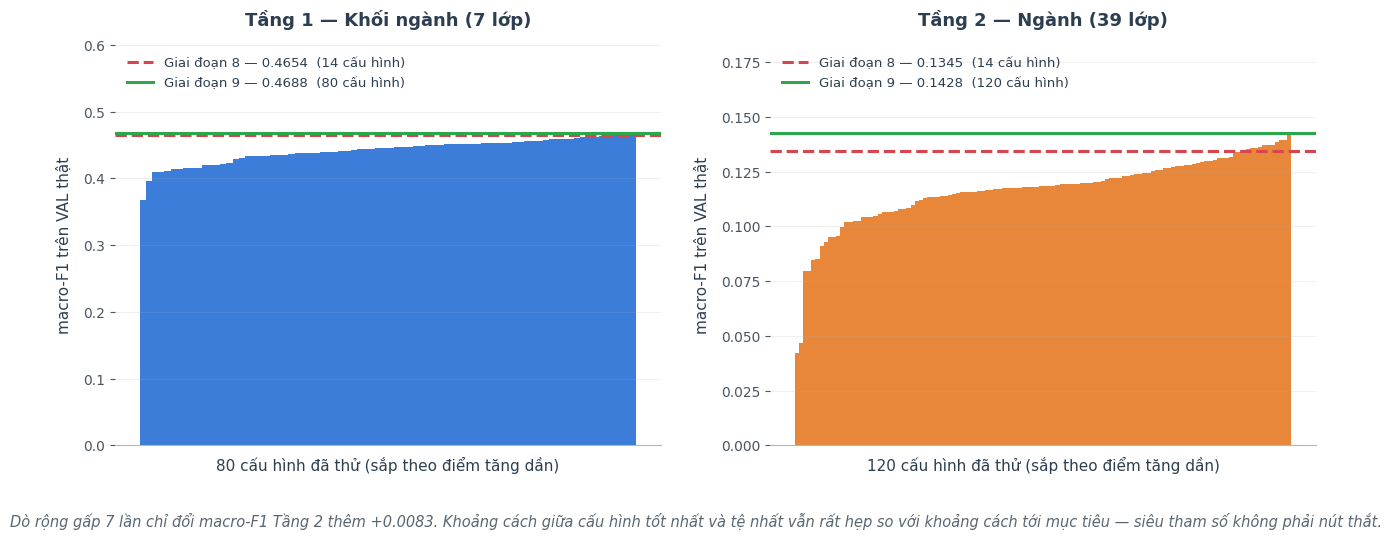

In [5]:
# ═══════════ HÌNH 9.1 — Dò rộng có ăn thua gì không ═══════════
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.2))
for ax, (tang, D) in zip(axes, [(1, D1), (2, D2)]):
    v = D.macro_f1.values[::-1]
    ax.bar(range(len(v)), v, color=C_XANH if tang == 1 else C_CAM,
           edgecolor="none", width=1.0)
    ax.axhline(GD8[tang], color=C_THAT, ls="--", lw=2.2,
               label=f"Giai đoạn 8 — {GD8[tang]:.4f}  (14 cấu hình)")
    ax.axhline(v.max(), color=C_GA, ls="-", lw=2.2,
               label=f"Giai đoạn 9 — {v.max():.4f}  ({len(v)} cấu hình)")
    ax.set_xlabel(f"{len(v)} cấu hình đã thử (sắp theo điểm tăng dần)")
    ax.set_ylabel("macro-F1 trên VAL thật")
    ax.set_title(f"Tầng {tang} — {'Khối ngành (7 lớp)' if tang == 1 else 'Ngành (39 lớp)'}")
    ax.legend(fontsize=9.5, loc="upper left"); ax.set_xticks([])
    ax.set_ylim(0, max(v.max(), GD8[tang]) * 1.28)
d2 = D2.macro_f1.iloc[0] - GD8[2]
chu_thich(fig, f"Dò rộng gấp {(80+120)/28:.0f} lần chỉ đổi macro-F1 Tầng 2 thêm {d2:+.4f}. "
               "Khoảng cách giữa cấu hình tốt nhất và tệ nhất vẫn rất hẹp so với "
               "khoảng cách tới mục tiêu — siêu tham số không phải nút thắt.")
luu(fig, OUTPUT_DIR, "hinh_9_1_do_rong.png")
plt.show()

   💾 Đã lưu hình: hinh_9_2_trong_so_nguon.png


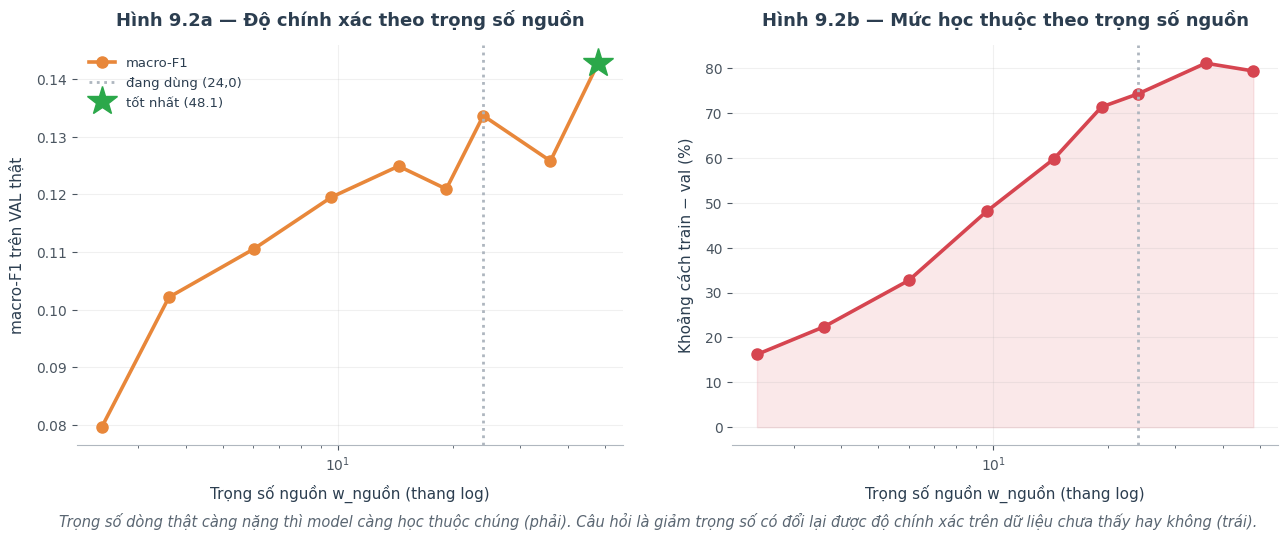

In [6]:
# ═══════════ HÌNH 9.2 — Trọng số nguồn ảnh hưởng thế nào ═══════════
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.2))

ax = axes[0]
ax.plot(QUET.w_nguon_hieu_dung, QUET.macro_f1, "o-", color=C_CAM, lw=2.6, ms=8,
        label="macro-F1")
ax.axvline(24.03, color=C_XAM, ls=":", lw=2, label="đang dùng (24,0)")
i = QUET.macro_f1.idxmax()
ax.plot(QUET.w_nguon_hieu_dung[i], QUET.macro_f1[i], "*", color=C_GA, ms=22,
        label=f"tốt nhất ({QUET.w_nguon_hieu_dung[i]:.1f})", zorder=5)
ax.set_xscale("log"); ax.set_xlabel("Trọng số nguồn w_nguồn (thang log)")
ax.set_ylabel("macro-F1 trên VAL thật")
ax.set_title("Hình 9.2a — Độ chính xác theo trọng số nguồn")
ax.legend(fontsize=9.5)

ax = axes[1]
ax.plot(QUET.w_nguon_hieu_dung, QUET.gap_train_val * 100, "o-", color=C_THAT, lw=2.6, ms=8)
ax.axvline(24.03, color=C_XAM, ls=":", lw=2)
ax.fill_between(QUET.w_nguon_hieu_dung, 0, QUET.gap_train_val * 100, color=C_THAT, alpha=0.12)
ax.set_xscale("log"); ax.set_xlabel("Trọng số nguồn w_nguồn (thang log)")
ax.set_ylabel("Khoảng cách train − val (%)")
ax.set_title("Hình 9.2b — Mức học thuộc theo trọng số nguồn")
chu_thich(fig, "Trọng số dòng thật càng nặng thì model càng học thuộc chúng (phải). "
               "Câu hỏi là giảm trọng số có đổi lại được độ chính xác trên dữ liệu "
               "chưa thấy hay không (trái).")
luu(fig, OUTPUT_DIR, "hinh_9_2_trong_so_nguon.png")
plt.show()

## Bước 9.5 — Kết luận

In [7]:
cai_thien_f1 = D2.macro_f1.iloc[0] - GD8[2]
tot_quet     = QUET.loc[QUET.macro_f1.idxmax()]
gap_hien_tai = float(QUET.loc[QUET.ty_le_that == 1.0, "gap_train_val"].iloc[0])

KL = {
    "n_cau_hinh_gd8": 28, "n_cau_hinh_gd9": int(N_THU[1] + N_THU[2]),
    "tang1": {"gd8": GD8[1], "gd9": float(D1.macro_f1.iloc[0]),
              "chenh": float(D1.macro_f1.iloc[0] - GD8[1])},
    "tang2": {"gd8": GD8[2], "gd9": float(D2.macro_f1.iloc[0]),
              "chenh": float(cai_thien_f1)},
    "trong_so_nguon": {"dang_dung": 24.03, "tot_nhat": float(tot_quet.w_nguon_hieu_dung),
                       "macro_f1_tot_nhat": float(tot_quet.macro_f1),
                       "gap_tai_24": gap_hien_tai,
                       "gap_tai_tot_nhat": float(tot_quet.gap_train_val)},
    "sieu_tham_so_tot_nhat": {"tang1": BEST_P1, "tang2": BEST_P2,
                              "ty_le_that": float(D2.iloc[0].ty_le_that)},
}
json.dump(KL, open(OUTPUT_DIR / "ket_luan_tinh_chinh.json", "w"),
          ensure_ascii=False, indent=1, default=float)

print("═" * 70)
print("  KẾT LUẬN GIAI ĐOẠN 9")
print("═" * 70)
print(f"  Số cấu hình đã thử : 28 (GĐ8)  →  {N_THU[1]+N_THU[2]} (GĐ9)")
print(f"  Tầng 1 macro-F1    : {GD8[1]:.4f}  →  {D1.macro_f1.iloc[0]:.4f}"
      f"   ({D1.macro_f1.iloc[0]-GD8[1]:+.4f})")
print(f"  Tầng 2 macro-F1    : {GD8[2]:.4f}  →  {D2.macro_f1.iloc[0]:.4f}"
      f"   ({cai_thien_f1:+.4f})")
print(f"  w_nguồn tốt nhất   : {tot_quet.w_nguon_hieu_dung:.1f} (đang dùng 24,0)")
print(f"  Học thuộc          : {gap_hien_tai:.1%} → {tot_quet.gap_train_val:.1%}")
print("─" * 70)
if cai_thien_f1 > 0.02:
    print("  ⇒ ĐÁNG ĐỔI: dò rộng tìm được cấu hình tốt hơn rõ rệt. Nên cập nhật GĐ8.")
elif cai_thien_f1 > 0.005:
    print("  ⇒ CẢI THIỆN NHẸ: có tiến bộ nhưng nhỏ. Cân nhắc cập nhật.")
else:
    print("  ⇒ ĐÃ CẠN: dò rộng gấp nhiều lần gần như không đổi kết quả.")
    print("     Đây là bằng chứng để kết luận siêu tham số KHÔNG phải nút thắt,")
    print("     và nút thắt nằm ở dữ liệu / độ phân biệt của bộ câu hỏi.")
print("═" * 70)

══════════════════════════════════════════════════════════════════════
  KẾT LUẬN GIAI ĐOẠN 9
══════════════════════════════════════════════════════════════════════
  Số cấu hình đã thử : 28 (GĐ8)  →  200 (GĐ9)
  Tầng 1 macro-F1    : 0.4654  →  0.4688   (+0.0034)
  Tầng 2 macro-F1    : 0.1345  →  0.1428   (+0.0083)
  w_nguồn tốt nhất   : 48.1 (đang dùng 24,0)
  Học thuộc          : 74.3% → 79.4%
──────────────────────────────────────────────────────────────────────
  ⇒ CẢI THIỆN NHẸ: có tiến bộ nhưng nhỏ. Cân nhắc cập nhật.
══════════════════════════════════════════════════════════════════════
